# **Project Name**  -Credit Card Fraud Detection


##### **Contribution**    - Individual
#####  Member Name  - DEVADHARSHINI M

# GitHub Link -

In [1]:
!pip install -q imbalanced-learn xgboost

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve
)

from imblearn.under_sampling import RandomUnderSampler
from imblearn.over_sampling import RandomOverSampler, SMOTE

from xgboost import XGBClassifier

import warnings
warnings.filterwarnings("ignore")

In [3]:
#dataset Load
url = "https://raw.githubusercontent.com/devadharshinimurugan06-commits/Credit-card_Syntecxhub_project/main/creditcard_small.csv"

df = pd.read_csv(url)

print("Dataset loaded successfully!")

Dataset loaded successfully!


In [4]:
#first five rows
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,38111.0,1.18447,0.17642,0.23681,1.15593,-0.41435,-0.98735,0.17278,-0.16918,0.17119,...,0.03141,0.00679,-0.11051,0.36477,0.63340,-0.32744,-0.00031,0.02295,34.84,0
1,74284.0,1.23605,0.28663,0.18687,0.50158,-0.16348,-0.56294,-0.03021,-0.02967,-0.18853,...,-0.25860,-0.78677,0.07744,-0.03985,0.22611,0.09765,-0.02806,0.01712,1.98,0
2,58439.0,-4.17432,3.79573,-1.63115,-0.06402,-2.55582,-1.36716,-1.83691,2.97837,-0.44500,...,-0.11177,-0.80630,0.37783,0.33804,0.27657,0.11282,0.02523,0.03309,9.03,0
3,48267.0,1.09204,-0.33308,0.86283,0.57924,-0.56797,0.56369,-0.59743,0.19892,0.55748,...,-0.05041,-0.05687,-0.15044,-0.45371,0.35651,0.34297,0.00852,0.02050,64.99,0
4,120633.0,1.84411,-1.43044,-0.63511,-0.88423,-1.07630,-0.18806,-0.85018,-0.00187,-0.21841,...,0.08235,-0.09556,0.19585,-0.47642,-0.53432,-0.49185,-0.01457,-0.02786,161.00,0


In [5]:
#shape
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 25492
Number of columns: 31


In [6]:
#dataset info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25492 entries, 0 to 25491
Data columns (total 31 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Time    25492 non-null  float64
 1   V1      25492 non-null  float64
 2   V2      25492 non-null  float64
 3   V3      25492 non-null  float64
 4   V4      25492 non-null  float64
 5   V5      25492 non-null  float64
 6   V6      25492 non-null  float64
 7   V7      25492 non-null  float64
 8   V8      25492 non-null  float64
 9   V9      25492 non-null  float64
 10  V10     25492 non-null  float64
 11  V11     25492 non-null  float64
 12  V12     25492 non-null  float64
 13  V13     25492 non-null  float64
 14  V14     25492 non-null  float64
 15  V15     25492 non-null  float64
 16  V16     25492 non-null  float64
 17  V17     25492 non-null  float64
 18  V18     25492 non-null  float64
 19  V19     25492 non-null  float64
 20  V20     25492 non-null  float64
 21  V21     25492 non-null  float64
 22

In [7]:
#describe
df.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,25492.000000,25492.000000,25492.000000,25492.000000,25492.000000,25492.000000,25492.000000,25492.000000,25492.000000,25492.000000,...,25492.000000,25492.000000,25492.000000,25492.000000,25492.000000,25492.000000,25492.000000,25492.000000,25492.000000,25492.000000
mean,94557.474776,-0.080751,0.070694,-0.123137,0.082312,-0.042171,-0.030701,-0.106870,0.017388,-0.037076,...,0.007975,0.000606,0.002065,-0.006100,-0.006177,0.003691,0.001955,0.001739,86.556449,0.019300
std,47456.259413,2.184385,1.727340,1.980655,1.558943,1.562120,1.335272,1.666121,1.459473,1.187338,...,0.869072,0.740147,0.603154,0.607030,0.526974,0.484625,0.437573,0.316968,214.510284,0.137581
min,0.000000,-30.552380,-32.494840,-31.103680,-4.938820,-22.325820,-17.282140,-43.557240,-41.044260,-13.434070,...,-22.797600,-8.887020,-19.254330,-2.836630,-4.781610,-1.581930,-9.543520,-8.307960,0.000000,0.000000
25%,54286.750000,-0.942802,-0.592215,-0.954562,-0.822172,-0.705732,-0.783212,-0.580815,-0.205632,-0.659787,...,-0.226322,-0.550553,-0.165217,-0.356828,-0.320922,-0.327110,-0.070965,-0.052683,5.360000,0.000000
50%,84546.500000,-0.010915,0.081775,0.154295,0.012985,-0.064195,-0.281765,0.030145,0.026300,-0.058345,...,-0.024640,0.007060,-0.010475,0.038585,0.013745,-0.046065,0.002275,0.011865,21.800000,0.000000
75%,139065.500000,1.299965,0.839477,1.007055,0.795445,0.619535,0.395033,0.573857,0.341975,0.589328,...,0.192050,0.527323,0.151630,0.432970,0.341525,0.250365,0.095400,0.081270,77.000000,0.000000
max,172768.000000,2.420350,22.057730,3.893020,12.155020,28.516510,15.323770,16.970600,20.007210,8.294220,...,27.202840,8.361990,17.751730,4.016340,5.852480,3.517350,9.879900,15.870470,6511.000000,1.000000


In [8]:
#check column
print(df.columns.tolist())

['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount', 'Class']


In [9]:
#missing value check
missing_values = df.isnull().sum()

print(missing_values[missing_values > 0])


Series([], dtype: int64)


In [10]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 27


In [11]:
#remove duplicate rows
df = df.drop_duplicates().reset_index(drop=True)

print("Dataset shape after removing duplicates:", df.shape)

Dataset shape after removing duplicates: (25465, 31)


In [12]:
#target col
print(df["Class"].value_counts())

Class
0    24992
1      473
Name: count, dtype: int64


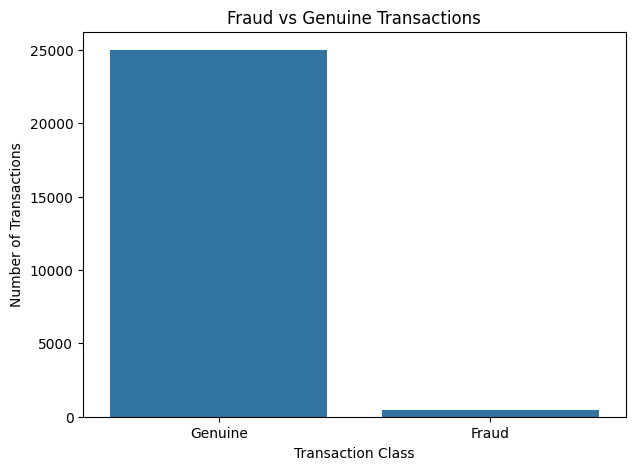

In [13]:
# EDA
# Class Distribution
plt.figure(figsize=(7,5))

sns.countplot(data=df, x="Class")

plt.title("Fraud vs Genuine Transactions")
plt.xlabel("Transaction Class")
plt.ylabel("Number of Transactions")
plt.xticks([0, 1], ["Genuine", "Fraud"])

plt.show()

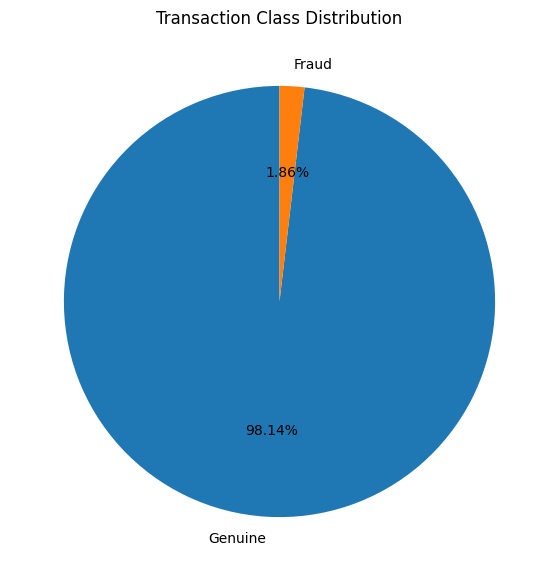

In [14]:
#pie chart
class_counts = df["Class"].value_counts()

plt.figure(figsize=(7,7))

plt.pie(
    class_counts,
    labels=["Genuine", "Fraud"],
    autopct="%1.2f%%",
    startangle=90
)

plt.title("Transaction Class Distribution")

plt.show()

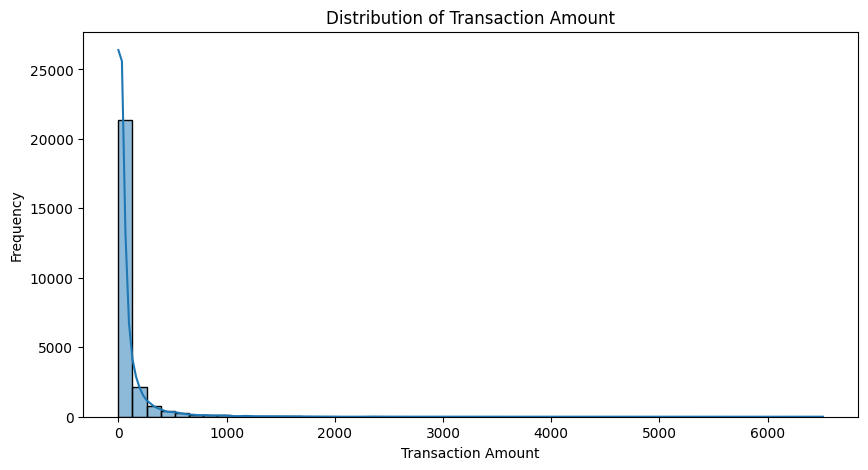

In [15]:
# transaction amt distribution
plt.figure(figsize=(10,5))

sns.histplot(
    data=df,
    x="Amount",
    bins=50,
    kde=True
)

plt.title("Distribution of Transaction Amount")
plt.xlabel("Transaction Amount")
plt.ylabel("Frequency")

plt.show()

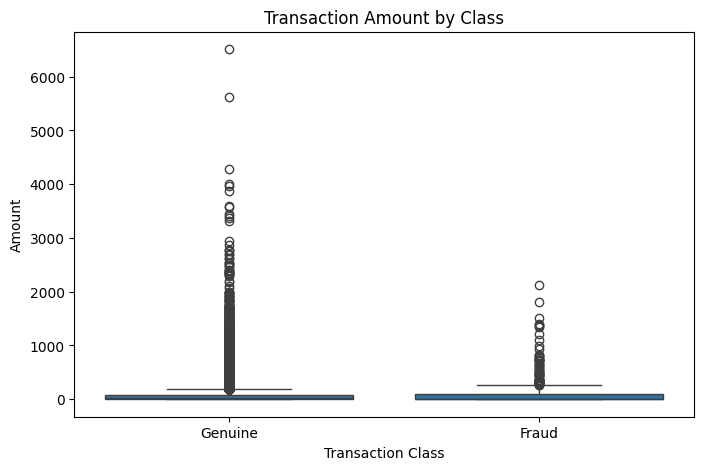

In [16]:
#Transaction amt by class
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="Class",
    y="Amount"
)

plt.title("Transaction Amount by Class")
plt.xlabel("Transaction Class")
plt.ylabel("Amount")
plt.xticks([0, 1], ["Genuine", "Fraud"])

plt.show()

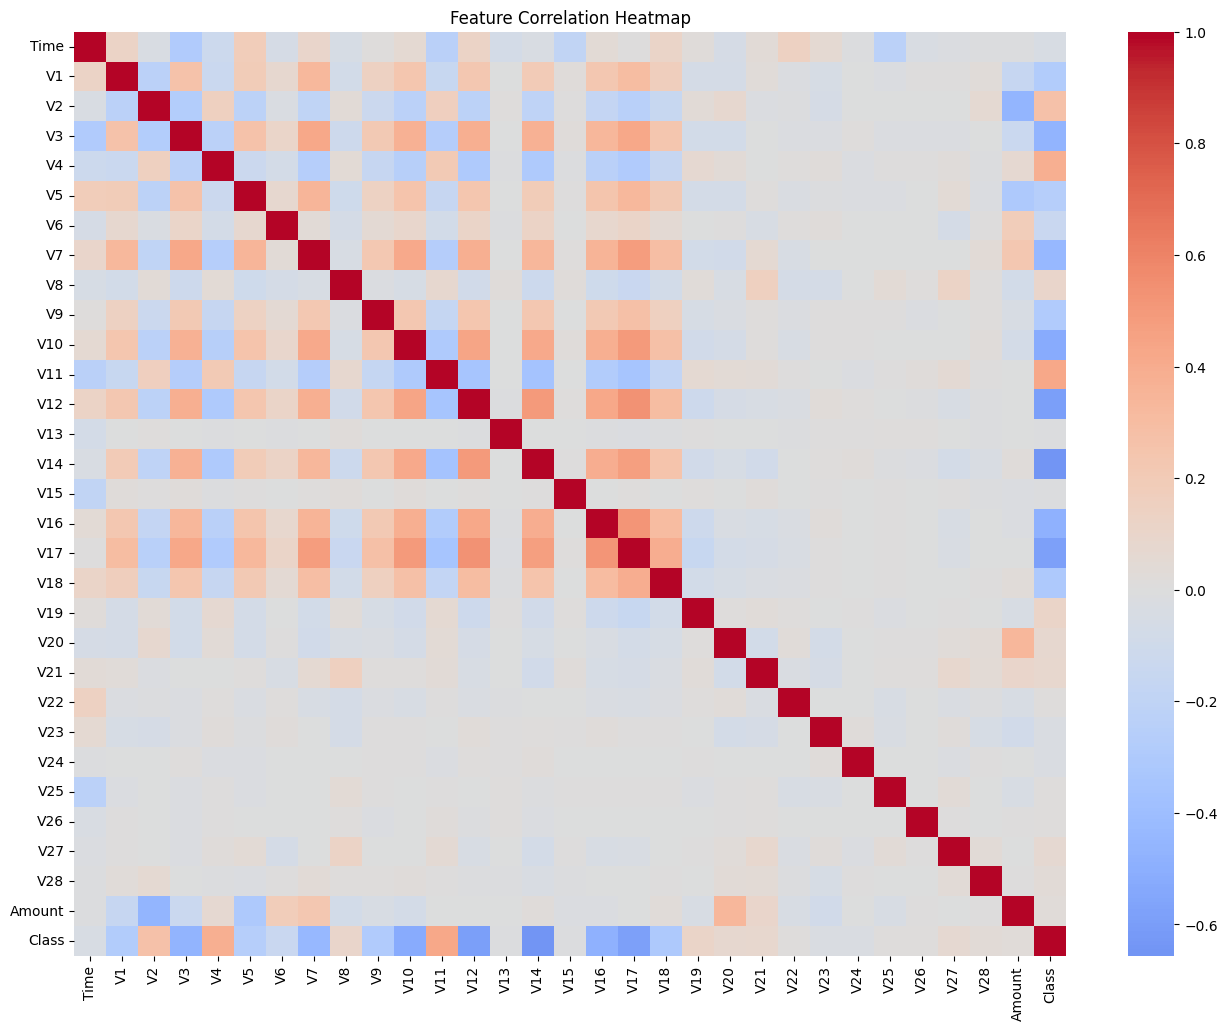

In [17]:
# correlation heatmap
plt.figure(figsize=(16,12))

correlation = df.corr()

sns.heatmap(
    correlation,
    cmap="coolwarm",
    center=0
)

plt.title("Feature Correlation Heatmap")

plt.show()

In [18]:
#class imablance
class_counts = df["Class"].value_counts()

class_percentage = (
    df["Class"]
    .value_counts(normalize=True)
    .mul(100)
)

print("Class Counts:")
print(class_counts)

print("\nClass Percentage:")
print(class_percentage)

Class Counts:
Class
0    24992
1      473
Name: count, dtype: int64

Class Percentage:
Class
0    98.142549
1     1.857451
Name: proportion, dtype: float64


In [19]:
# class imabalance ratio
imbalance_ratio = class_counts[0] / class_counts[1]

print("Imbalance Ratio:", round(imbalance_ratio, 2))

Imbalance Ratio: 52.84


In [21]:
print("Average amount by class:")
print(df.groupby("Class")["Amount"].mean())

print("\nMedian amount by class:")
print(df.groupby("Class")["Amount"].median())

Average amount by class:
Class
0     85.873186
1    123.871860
Name: Amount, dtype: float64

Median amount by class:
Class
0    21.95
1     9.82
Name: Amount, dtype: float64


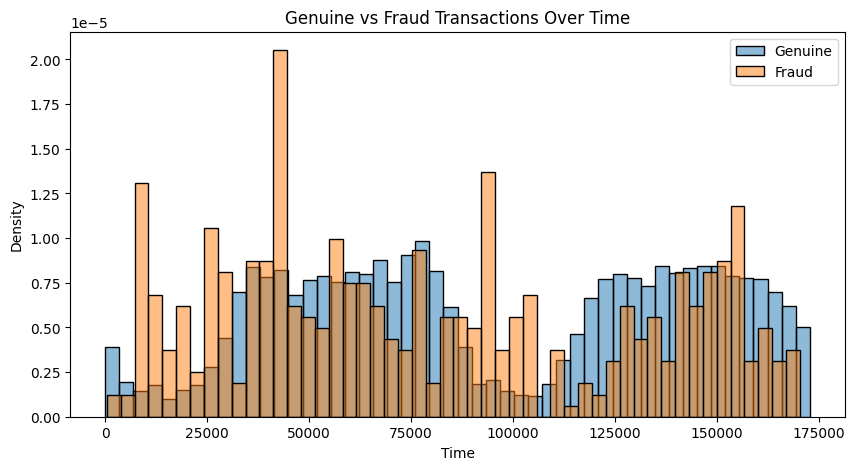

In [22]:
plt.figure(figsize=(10, 5))

sns.histplot(
    data=df[df["Class"] == 0],
    x="Time",
    bins=50,
    stat="density",
    alpha=0.5,
    label="Genuine"
)

sns.histplot(
    data=df[df["Class"] == 1],
    x="Time",
    bins=50,
    stat="density",
    alpha=0.5,
    label="Fraud"
)

plt.title("Genuine vs Fraud Transactions Over Time")
plt.xlabel("Time")
plt.ylabel("Density")
plt.legend()

plt.show()

In [23]:
# Separate features and target
X = df.drop("Class", axis=1)
y = df["Class"]

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training set shape:", X_train.shape)
print("Testing set shape:", X_test.shape)

print("\nTraining class distribution:")
print(y_train.value_counts())

print("\nTesting class distribution:")
print(y_test.value_counts())

Training set shape: (20372, 30)
Testing set shape: (5093, 30)

Training class distribution:
Class
0    19994
1      378
Name: count, dtype: int64

Testing class distribution:
Class
0    4998
1      95
Name: count, dtype: int64


Random Forest -ML Implementation

In [25]:
# Random Forest

rf_baseline = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

# Train on original imbalanced training data
rf_baseline.fit(X_train, y_train)

# Predictions
y_pred_rf = rf_baseline.predict(X_test)
y_prob_rf = rf_baseline.predict_proba(X_test)[:, 1]

print("Random Forest Baseline trained successfully!")

# Evaluate Random Forest Baseline

rf_precision = precision_score(y_test, y_pred_rf, zero_division=0)
rf_recall = recall_score(y_test, y_pred_rf, zero_division=0)
rf_f1 = f1_score(y_test, y_pred_rf, zero_division=0)
rf_auc = roc_auc_score(y_test, y_prob_rf)

print("Random Forest Baseline Results")
print("--------------------------------")
print("Precision :", round(rf_precision, 4))
print("Recall    :", round(rf_recall, 4))
print("F1 Score  :", round(rf_f1, 4))
print("ROC-AUC   :", round(rf_auc, 4))

Random Forest Baseline trained successfully!
Random Forest Baseline Results
--------------------------------
Precision : 0.9872
Recall    : 0.8105
F1 Score  : 0.8902
ROC-AUC   : 0.9747


In [26]:
# Random Undersampling

under_sampler = RandomUnderSampler(random_state=42)

X_train_under, y_train_under = under_sampler.fit_resample(
    X_train, y_train
)

print("Before Undersampling:")
print(y_train.value_counts())

print("\nAfter Undersampling:")
print(y_train_under.value_counts())

Before Undersampling:
Class
0    19994
1      378
Name: count, dtype: int64

After Undersampling:
Class
0    378
1    378
Name: count, dtype: int64


In [28]:
# Random Forest with Undersampling

rf_under = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

# Train only on undersampled training data
rf_under.fit(X_train_under, y_train_under)

# Predict on the ORIGINAL untouched test set
y_pred_under = rf_under.predict(X_test)
y_prob_under = rf_under.predict_proba(X_test)[:, 1]

print("Random Forest with Undersampling trained successfully!")

# Evaluate Undersampling Model

under_precision = precision_score(y_test, y_pred_under, zero_division=0)
under_recall = recall_score(y_test, y_pred_under, zero_division=0)
under_f1 = f1_score(y_test, y_pred_under, zero_division=0)
under_auc = roc_auc_score(y_test, y_prob_under)

print("Random Forest - Undersampling Results")
print("--------------------------------------")
print("Precision :", round(under_precision, 4))
print("Recall    :", round(under_recall, 4))
print("F1 Score  :", round(under_f1, 4))
print("ROC-AUC   :", round(under_auc, 4))

Random Forest with Undersampling trained successfully!
Random Forest - Undersampling Results
--------------------------------------
Precision : 0.4028
Recall    : 0.9158
F1 Score  : 0.5595
ROC-AUC   : 0.9722


In [29]:
# Random Oversampling

over_sampler = RandomOverSampler(random_state=42)

X_train_over, y_train_over = over_sampler.fit_resample(
    X_train, y_train
)

print("Before Oversampling:")
print(y_train.value_counts())

print("\nAfter Oversampling:")
print(y_train_over.value_counts())

Before Oversampling:
Class
0    19994
1      378
Name: count, dtype: int64

After Oversampling:
Class
0    19994
1    19994
Name: count, dtype: int64


In [31]:
# Random Forest with Oversampling

rf_over = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

# Train on oversampled training data
rf_over.fit(X_train_over, y_train_over)

# Predict on original untouched test data
y_pred_over = rf_over.predict(X_test)
y_prob_over = rf_over.predict_proba(X_test)[:, 1]

print("Random Forest with Oversampling trained successfully!")

# Evaluate Oversampling Model

over_precision = precision_score(y_test, y_pred_over, zero_division=0)
over_recall = recall_score(y_test, y_pred_over, zero_division=0)
over_f1 = f1_score(y_test, y_pred_over, zero_division=0)
over_auc = roc_auc_score(y_test, y_prob_over)

print("Random Forest - Oversampling Results")
print("------------------------------------")
print("Precision :", round(over_precision, 4))
print("Recall    :", round(over_recall, 4))
print("F1 Score  :", round(over_f1, 4))
print("ROC-AUC   :", round(over_auc, 4))

Random Forest with Oversampling trained successfully!
Random Forest - Oversampling Results
------------------------------------
Precision : 0.9873
Recall    : 0.8211
F1 Score  : 0.8966
ROC-AUC   : 0.9803


XG-Boost -ML Implementation

In [33]:
# XGBoost

xgb_baseline = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric="logloss"
)

# Train on original imbalanced training data
xgb_baseline.fit(X_train, y_train)

# Predictions on untouched test data
y_pred_xgb = xgb_baseline.predict(X_test)
y_prob_xgb = xgb_baseline.predict_proba(X_test)[:, 1]

print("XGBoost Baseline trained successfully!")

# Evaluate XGBoost Baseline

xgb_precision = precision_score(y_test, y_pred_xgb, zero_division=0)
xgb_recall = recall_score(y_test, y_pred_xgb, zero_division=0)
xgb_f1 = f1_score(y_test, y_pred_xgb, zero_division=0)
xgb_auc = roc_auc_score(y_test, y_prob_xgb)

print("XGBoost Baseline Results")
print("------------------------")
print("Precision :", round(xgb_precision, 4))
print("Recall    :", round(xgb_recall, 4))
print("F1 Score  :", round(xgb_f1, 4))
print("ROC-AUC   :", round(xgb_auc, 4))

XGBoost Baseline trained successfully!
XGBoost Baseline Results
------------------------
Precision : 0.9873
Recall    : 0.8211
F1 Score  : 0.8966
ROC-AUC   : 0.9835


In [34]:
# XGBoost with Undersampling

xgb_under = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric="logloss"
)

# Train on undersampled training data
xgb_under.fit(X_train_under, y_train_under)

# Predict on untouched test data
y_pred_xgb_under = xgb_under.predict(X_test)
y_prob_xgb_under = xgb_under.predict_proba(X_test)[:, 1]

# Metrics
xgb_under_precision = precision_score(y_test, y_pred_xgb_under, zero_division=0)
xgb_under_recall = recall_score(y_test, y_pred_xgb_under, zero_division=0)
xgb_under_f1 = f1_score(y_test, y_pred_xgb_under, zero_division=0)
xgb_under_auc = roc_auc_score(y_test, y_prob_xgb_under)

print("XGBoost + Undersampling Results")
print("--------------------------------")
print("Precision :", round(xgb_under_precision, 4))
print("Recall    :", round(xgb_under_recall, 4))
print("F1 Score  :", round(xgb_under_f1, 4))
print("ROC-AUC   :", round(xgb_under_auc, 4))

XGBoost + Undersampling Results
--------------------------------
Precision : 0.3358
Recall    : 0.9474
F1 Score  : 0.4959
ROC-AUC   : 0.9753


In [35]:
# XGBoost with Oversampling

xgb_over = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric="logloss"
)

# Train on oversampled training data
xgb_over.fit(X_train_over, y_train_over)

# Predict on untouched test data
y_pred_xgb_over = xgb_over.predict(X_test)
y_prob_xgb_over = xgb_over.predict_proba(X_test)[:, 1]

# Metrics
xgb_over_precision = precision_score(y_test, y_pred_xgb_over, zero_division=0)
xgb_over_recall = recall_score(y_test, y_pred_xgb_over, zero_division=0)
xgb_over_f1 = f1_score(y_test, y_pred_xgb_over, zero_division=0)
xgb_over_auc = roc_auc_score(y_test, y_prob_xgb_over)

print("XGBoost + Oversampling Results")
print("------------------------------")
print("Precision :", round(xgb_over_precision, 4))
print("Recall    :", round(xgb_over_recall, 4))
print("F1 Score  :", round(xgb_over_f1, 4))
print("ROC-AUC   :", round(xgb_over_auc, 4))

XGBoost + Oversampling Results
------------------------------
Precision : 0.9412
Recall    : 0.8421
F1 Score  : 0.8889
ROC-AUC   : 0.9737


In [36]:
# Final Model Comparison Table

results = pd.DataFrame({
    "Model": [
        "RF Baseline",
        "RF + Undersampling",
        "RF + Oversampling",
        "XGBoost Baseline",
        "XGBoost + Undersampling",
        "XGBoost + Oversampling"
    ],
    "Precision": [
        rf_precision,
        under_precision,
        over_precision,
        xgb_precision,
        xgb_under_precision,
        xgb_over_precision
    ],
    "Recall": [
        rf_recall,
        under_recall,
        over_recall,
        xgb_recall,
        xgb_under_recall,
        xgb_over_recall
    ],
    "F1 Score": [
        rf_f1,
        under_f1,
        over_f1,
        xgb_f1,
        xgb_under_f1,
        xgb_over_f1
    ],
    "ROC-AUC": [
        rf_auc,
        under_auc,
        over_auc,
        xgb_auc,
        xgb_under_auc,
        xgb_over_auc
    ]
})

results = results.round(4)

print(results)

                     Model  Precision  Recall  F1 Score  ROC-AUC
0              RF Baseline     0.9872  0.8105    0.8902   0.9747
1       RF + Undersampling     0.4028  0.9158    0.5595   0.9722
2        RF + Oversampling     0.9873  0.8211    0.8966   0.9803
3         XGBoost Baseline     0.9873  0.8211    0.8966   0.9835
4  XGBoost + Undersampling     0.3358  0.9474    0.4959   0.9753
5   XGBoost + Oversampling     0.9412  0.8421    0.8889   0.9737


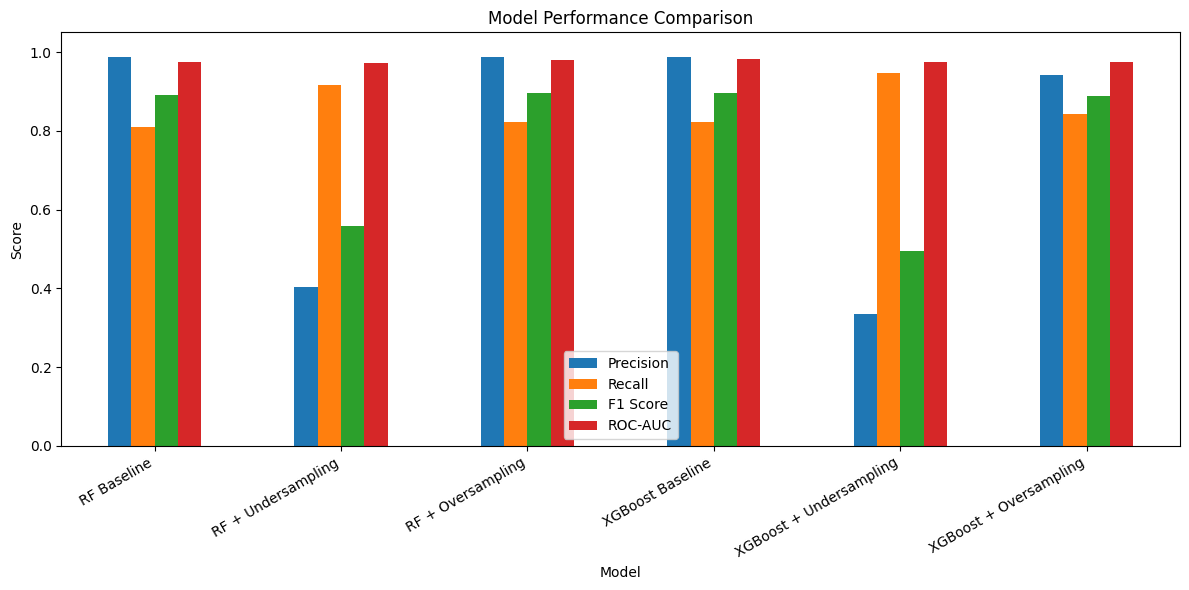

In [37]:
# Model Performance Comparison

results.set_index("Model")[["Precision", "Recall", "F1 Score", "ROC-AUC"]].plot(
    kind="bar",
    figsize=(12, 6)
)

plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.xlabel("Model")
plt.xticks(rotation=30, ha="right")
plt.ylim(0, 1.05)
plt.legend()
plt.tight_layout()
plt.show()

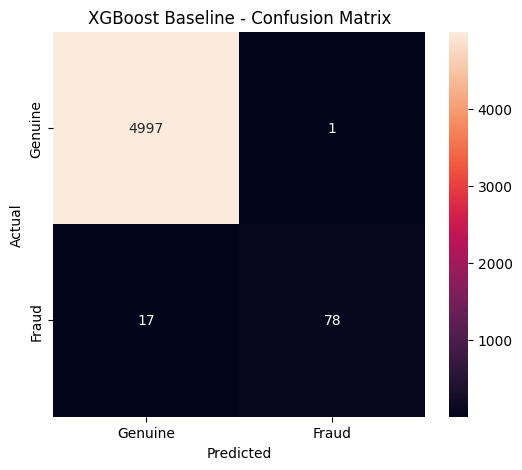

In [38]:
# Confusion Matrix - XGBoost Baseline

cm = confusion_matrix(y_test, y_pred_xgb)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=["Genuine", "Fraud"],
    yticklabels=["Genuine", "Fraud"]
)

plt.title("XGBoost Baseline - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

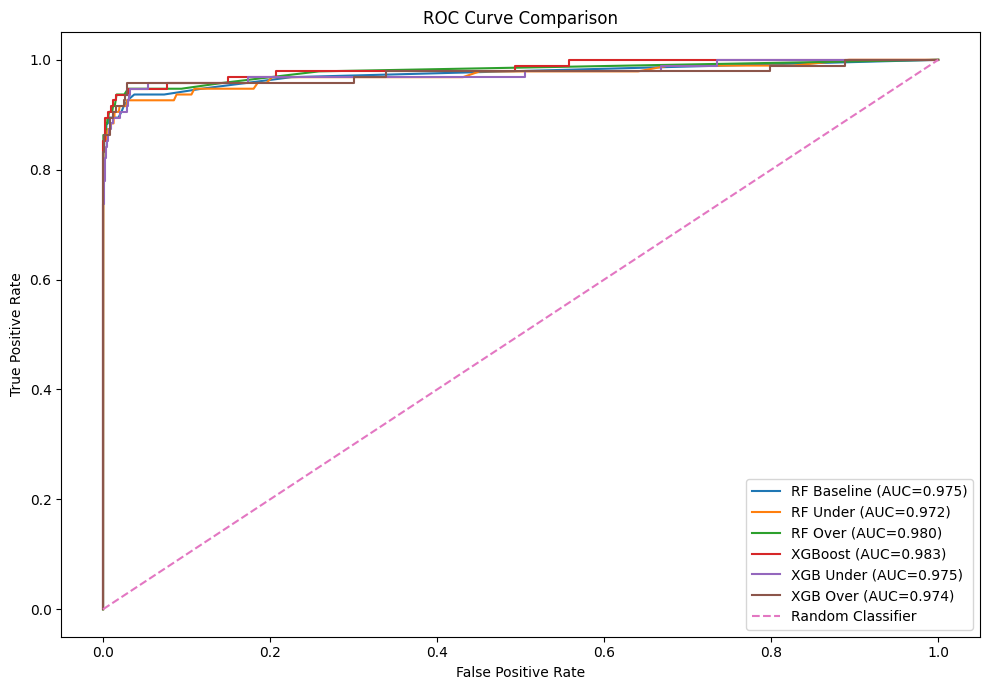

In [39]:
# ROC Curve Comparison

fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)
fpr_rf_under, tpr_rf_under, _ = roc_curve(y_test, y_prob_under)
fpr_rf_over, tpr_rf_over, _ = roc_curve(y_test, y_prob_over)

fpr_xgb, tpr_xgb, _ = roc_curve(y_test, y_prob_xgb)
fpr_xgb_under, tpr_xgb_under, _ = roc_curve(y_test, y_prob_xgb_under)
fpr_xgb_over, tpr_xgb_over, _ = roc_curve(y_test, y_prob_xgb_over)

plt.figure(figsize=(10, 7))

plt.plot(fpr_rf, tpr_rf, label=f"RF Baseline (AUC={rf_auc:.3f})")
plt.plot(fpr_rf_under, tpr_rf_under, label=f"RF Under (AUC={under_auc:.3f})")
plt.plot(fpr_rf_over, tpr_rf_over, label=f"RF Over (AUC={over_auc:.3f})")

plt.plot(fpr_xgb, tpr_xgb, label=f"XGBoost (AUC={xgb_auc:.3f})")
plt.plot(fpr_xgb_under, tpr_xgb_under, label=f"XGB Under (AUC={xgb_under_auc:.3f})")
plt.plot(fpr_xgb_over, tpr_xgb_over, label=f"XGB Over (AUC={xgb_over_auc:.3f})")

plt.plot([0, 1], [0, 1], "--", label="Random Classifier")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.tight_layout()
plt.show()

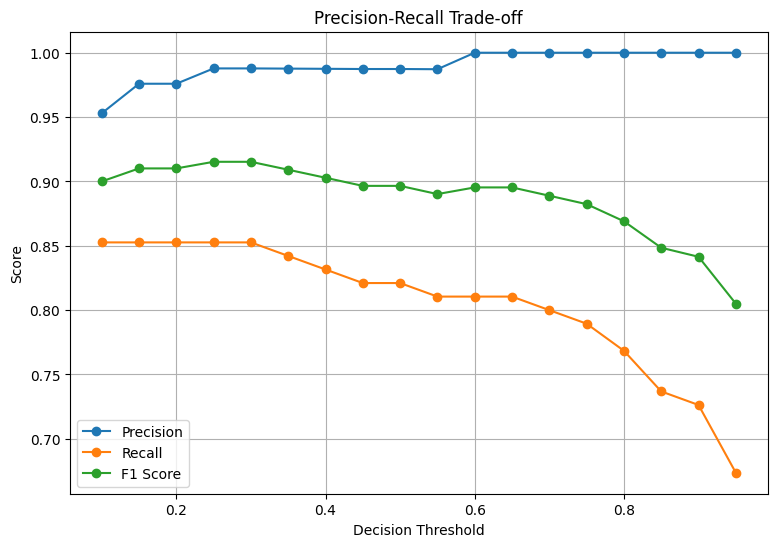

In [41]:
# Precision recall trade off
plt.figure(figsize=(9, 6))

plt.plot(
    threshold_df["Threshold"],
    threshold_df["Precision"],
    marker="o",
    label="Precision"
)

plt.plot(
    threshold_df["Threshold"],
    threshold_df["Recall"],
    marker="o",
    label="Recall"
)

plt.plot(
    threshold_df["Threshold"],
    threshold_df["F1 Score"],
    marker="o",
    label="F1 Score"
)

plt.xlabel("Decision Threshold")
plt.ylabel("Score")
plt.title("Precision-Recall Trade-off")
plt.legend()
plt.grid(True)
plt.show()

 Business Use Case:
Credit card fraud detection aims to identify fraudulent transactions while minimizing false alerts on genuine transactions. Since fraudulent transactions are rare, accuracy alone is not a reliable evaluation metric. Precision is important because false fraud alerts may inconvenience genuine customers, while recall is important because missing a fraudulent transaction can result in financial loss. Therefore, the decision threshold can be adjusted based on the business requirement. A lower threshold increases fraud detection recall but may generate more false positives, whereas a higher threshold improves precision but may miss more fraudulent transactions.

In [42]:
# Best threshold based on F1 Score

best_threshold_row = threshold_df.loc[
    threshold_df["F1 Score"].idxmax()
]

print("Best Threshold:", best_threshold_row["Threshold"])
print("Precision:", round(best_threshold_row["Precision"], 4))
print("Recall:", round(best_threshold_row["Recall"], 4))
print("F1 Score:", round(best_threshold_row["F1 Score"], 4))

Best Threshold: 0.25000000000000006
Precision: 0.9878
Recall: 0.8526
F1 Score: 0.9153


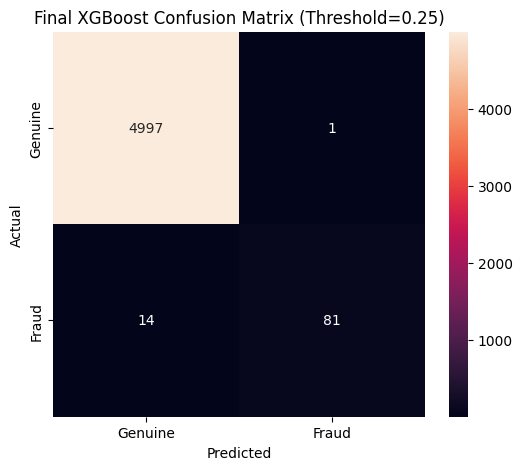

In [43]:
# Final predictions using best F1 threshold

best_threshold = best_threshold_row["Threshold"]

y_pred_final = (
    y_prob_xgb >= best_threshold
).astype(int)

final_cm = confusion_matrix(y_test, y_pred_final)

plt.figure(figsize=(6, 5))

sns.heatmap(
    final_cm,
    annot=True,
    fmt="d",
    xticklabels=["Genuine", "Fraud"],
    yticklabels=["Genuine", "Fraud"]
)

plt.title(
    f"Final XGBoost Confusion Matrix "
    f"(Threshold={best_threshold:.2f})"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()